**Q Learning**

Step 1: Define the Environment

We first define the environment including the number of states, actions, goal state and the Q-table. Each state represents a position in a 4×4 grid and actions represent movements in four directions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n_states = 16
n_actions = 4
goal_state = 15

Q_table = np.zeros((n_states, n_actions))

Step 2: Set Hyperparameters

These parameters control the learning process:

learning_rate (α): How much new info overrides old info.

discount_factor (γ): How much future rewards are valued.

exploration_prob (ε): Probability of taking a random action.

epochs: Number of training episodes.

In [2]:
learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000

Step 3: Define the State Transition Function

This function calculates the next state based on the current state and chosen action.

We assume:

0 → Left

1 → Right

2 → Up

3 → Down

In [3]:
def get_next_state(state, action):
    row, col = divmod(state, 4)

    if action == 0 and col > 0:
        col -= 1
    elif action == 1 and col < 3:
        col += 1
    elif action == 2 and row > 0:
        row -= 1
    elif action == 3 and row < 3:
        row += 1

    return row * 4 + col

Step 4: Implement the Q-Learning Algorithm

In [4]:
for epoch in range(epochs):
    current_state = np.random.randint(0, n_states)

    while True:
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)
        else:
            action = np.argmax(Q_table[current_state])

        next_state = get_next_state(current_state, action)

        reward = 1 if next_state == goal_state else 0

        Q_table[current_state, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action]
        )

        if next_state == goal_state:
            break

        current_state = next_state

Step 5: Output the Learned Q-Table

After training, we visualize the maximum Q-value of each state on a grid and print the learned Q-table. States closer to the goal should have higher Q-values, showing the agent’s learned path.

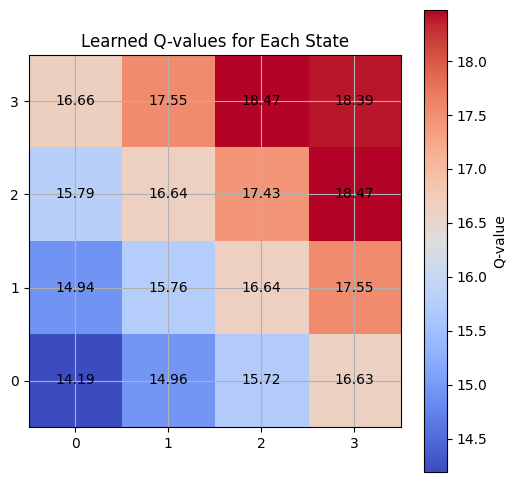

Learned Q-table:
[[13.27742414  8.09888765  9.55414935 14.19111884]
 [12.39694589 14.49830625 13.07454822 14.95896537]
 [12.93965672 13.57122163 12.20427506 15.7206177 ]
 [13.67171855 12.59894772 14.96034587 16.62502824]
 [13.95110191 14.27529815 13.12278166 14.94075079]
 [13.24939384 14.54666049 13.05911838 15.76068345]
 [10.92715137 16.64218784 14.45548368 15.89433869]
 [15.5791333  16.53228344 15.57644269 17.54768478]
 [14.88065691 14.82820475 13.39483468 15.79189994]
 [14.73025525 16.2224359  14.52995892 16.63857996]
 [15.02859273 17.42559958 15.1100154  16.88319243]
 [16.3889037  17.42476654 15.82027735 18.47339801]
 [15.56542919 16.66077282 14.86276824 15.44947844]
 [15.7519502  17.54802004 15.67210402 16.54004282]
 [16.58280045 18.47340141 15.88599551 17.40668204]
 [17.11519472 18.39307643 12.24501632 14.3070702 ]]


In [5]:
q_values_grid = np.max(Q_table, axis=1).reshape((4, 4))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for Each State')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()
plt.grid(True)

for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

print("Learned Q-table:")
print(Q_table)